# I wrote the same GPU operation six ways

This output-complete notebook asks when it is worth moving below NumPy and ordinary CuPy to write a custom CUDA kernel. The workload is a realistic row-scoring primitive: standardize every feature, clip outliers, apply feature weights, reduce each row, and emit a threshold flag.

The point is not to crown handwritten CUDA. It is to expose the layers that decide whether an optimization survives contact with a real pipeline: compilation, launch overhead, transfer, fusion, layout, and occupancy.

All figures below are reconstructed from the four sanitized CSVs committed with this notebook. You can inspect and rerun the analysis without a GPU. The full GPU harness is under `full-benchmark/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
RESULTS = HERE / "results"
launch = pd.read_csv(RESULTS / "published_launch_results.csv")
transfer = pd.read_csv(RESULTS / "published_transfer_results.csv")
fusion = pd.read_csv(RESULTS / "published_fusion_results.csv")
profiles = pd.read_csv(RESULTS / "published_profile_results.csv")

COLORS = {
    "NumPy": "#64748b",
    "Composed CuPy": "#2563eb",
    "Partial fusion": "#7c3aed",
    "Raw CUDA, row-major": "#ea580c",
    "Raw CUDA, feature-major": "#059669",
    "Raw CUDA, padded stride": "#dc2626",
}
LABELS = {
    "numpy": "NumPy",
    "cupy_composed": "Composed CuPy",
    "cupy_partial_fusion": "Partial fusion",
    "raw_aos_b256": "Raw CUDA, row-major",
    "raw_soa_b256": "Raw CUDA, feature-major",
    "raw_strided_b256": "Raw CUDA, padded stride",
}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False})

pd.DataFrame(
    {
        "evidence table": ["launch", "transfer", "fusion", "profiles"],
        "rows": [len(launch), len(transfer), len(fusion), len(profiles)],
    }
)

,evidence table,rows
0,launch,8
1,transfer,24
2,fusion,102
3,profiles,5


## Evidence controls

The timing matrix uses seven measured trials in each of three fresh processes. GPU implementations were checked against the NumPy score and flag arrays before their timings were admitted. Raw JSON, logs, and Nsight Compute reports remain private; these tables preserve the medians, replication ranges, correctness statistics, kernel attributes, and selected profiler counters used here.

In [2]:
assert launch["replications"].eq(3).all()
assert transfer["replications"].eq(3).all()
assert fusion["replications"].ge(3).all()
assert (fusion["max_abs_score_error"] <= 3e-4).all()
assert fusion.loc[fusion["flag_mismatches"] > 0, "max_abs_score_error"].le(3e-4).all()
assert set(profiles["layout"]) == {"aos", "soa"}

pd.DataFrame(
    {
        "check": ["fresh-process replications", "largest score error", "largest flag mismatch count", "timed fusion conditions"],
        "observed": [
            int(fusion["replications"].min()),
            f"{fusion['max_abs_score_error'].max():.7f}",
            int(fusion["flag_mismatches"].max()),
            len(fusion),
        ],
    }
)

,check,observed
0,fresh-process replications,3
1,largest score error,0.0001373
2,largest flag mismatch count,2
3,timed fusion conditions,102


## The implementations include useful and deliberately bad choices

For row $r$ and feature $f$:

$$z_{r,f}=\operatorname{clip}((x_{r,f}-\mu_f)\sigma_f^{-1},-5,5)$$

$$s_r=\sum_f z_{r,f}w_f,\qquad flag_r=(s_r>0)$$

- **NumPy** is the CPU reference.
- **Composed CuPy** expresses the work naturally but creates intermediates and launches several kernels.
- **Partial fusion** uses `ElementwiseKernel` for standardize/clip/weight, then leaves reduction and thresholding to CuPy.
- **Raw row-major CUDA** fuses the full row operation, but adjacent threads walk different rows.
- **Raw feature-major CUDA** performs the same arithmetic with adjacent threads reading adjacent addresses.
- **Padded-stride CUDA** is intentionally awkward: it increases the distance between adjacent row reads without changing the answer.

The comparison therefore shows both good and bad implementations, not just an optimized finish line.

## 1. A microsecond kernel can be mostly submission overhead

The launch calibration queues the same tiny operation 1, 10, 100, or 1,000 times and synchronizes once. Batching reveals the steady submission floor; a single synchronized launch includes more fixed cost.

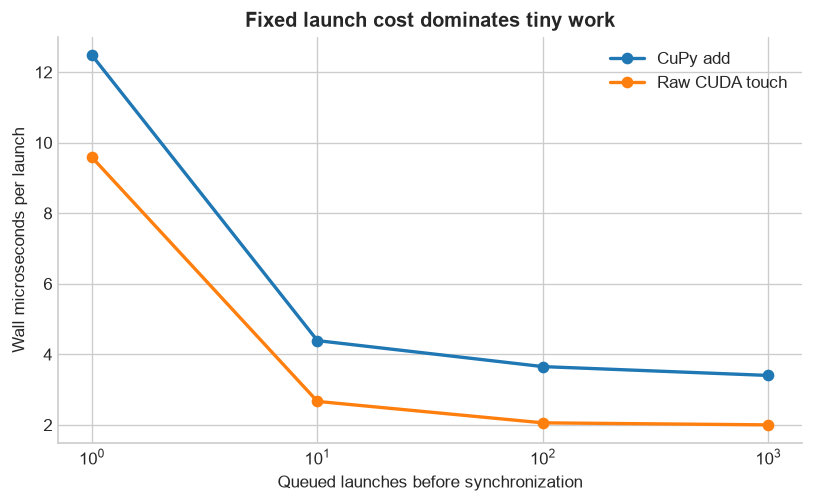

implementation,cupy_add,raw_touch
launches_per_trial,,
1,12.480,9.586
10,4.390,2.667
100,3.654,2.059
1000,3.403,2.002


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.4))
for implementation, frame in launch.groupby("implementation"):
    label = {"cupy_add": "CuPy add", "raw_touch": "Raw CUDA touch"}[implementation]
    ax.plot(frame["launches_per_trial"], frame["wall_microseconds_per_launch"], marker="o", linewidth=2, label=label)
ax.set_xscale("log")
ax.set_xlabel("Queued launches before synchronization")
ax.set_ylabel("Wall microseconds per launch")
ax.set_title("Fixed launch cost dominates tiny work")
ax.legend(frameon=False)
plt.show()

launch.pivot(index="launches_per_trial", columns="implementation", values="wall_microseconds_per_launch").round(3)

At 1,000 queued launches, the raw no-op-like kernel still costs about **2.00 μs per launch**, while the CuPy add costs **3.40 μs**. The first launch is slower because this path also pays cold compilation—roughly **0.10 seconds** for the raw touch kernel. Fusion matters most when it removes enough launches or intermediate memory traffic to repay these fixed costs.

## 2. The bus has a minimum useful dose too

Pinned memory helps large copies, but setup and synchronization dominate tiny payloads. Allocation is excluded here: buffers are created before timing.

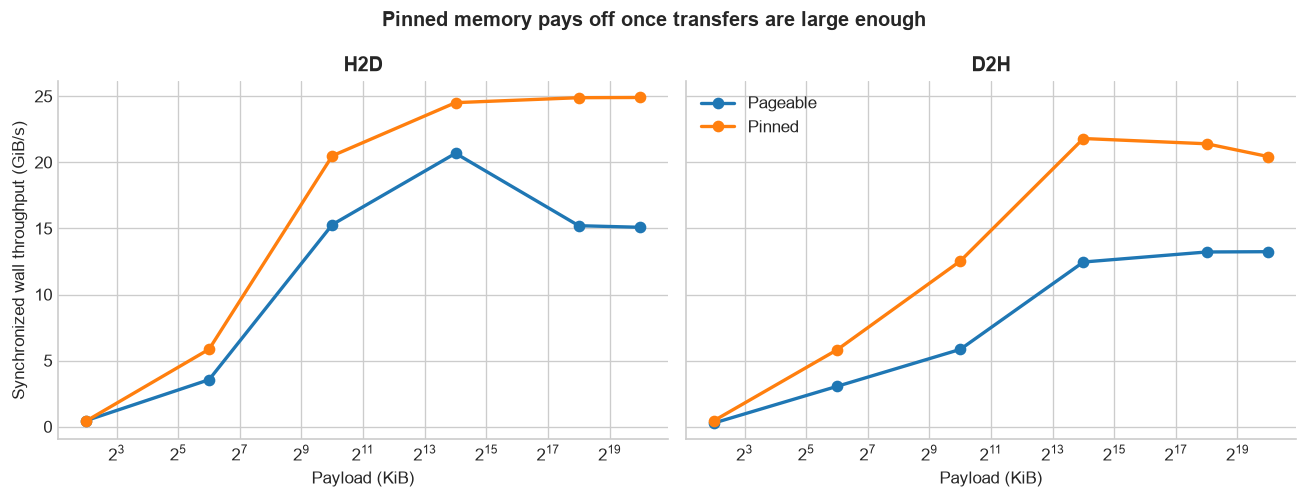

memory                pageable  pinned
bytes      direction                  
1048576    d2h            5.85   12.53
           h2d           15.29   20.49
268435456  d2h           13.22   21.40
           h2d           15.21   24.89
1073741824 d2h           13.24   20.44
           h2d           15.09   24.91

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, direction in zip(axes, ["h2d", "d2h"]):
    part = transfer[transfer["direction"] == direction]
    for memory, frame in part.groupby("memory"):
        ax.plot(frame["kib"], frame["wall_gib_per_second"], marker="o", linewidth=2, label=memory.title())
    ax.set_xscale("log", base=2)
    ax.set_xlabel("Payload (KiB)")
    ax.set_title(direction.upper())
axes[0].set_ylabel("Synchronized wall throughput (GiB/s)")
axes[1].legend(frameon=False)
fig.suptitle("Pinned memory pays off once transfers are large enough", fontweight="bold")
fig.tight_layout()
plt.show()

transfer[transfer["bytes"].isin([1 << 20, 1 << 28, 1 << 30])].pivot_table(
    index=["bytes", "direction"], columns="memory", values="wall_gib_per_second"
).round(2)

For 1 GiB transfers, pinned memory reaches **24.91 GiB/s H2D** and **20.44 GiB/s D2H**, versus **15.09** and **13.24 GiB/s** for pageable memory. At 4 KiB, every path stays below 0.5 GiB/s. “PCIe bandwidth” is not one number; payload size, direction, memory type, allocation policy, and synchronization all matter.

## 3. Fusion wins twice—fewer launches and less memory traffic

The next view fixes the workload at 1,048,576 rows × 16 features. “Resident” means inputs are already on the GPU and output allocation is included. “One shot” also includes pageable host-to-device input transfer and score/flag materialization back to NumPy.

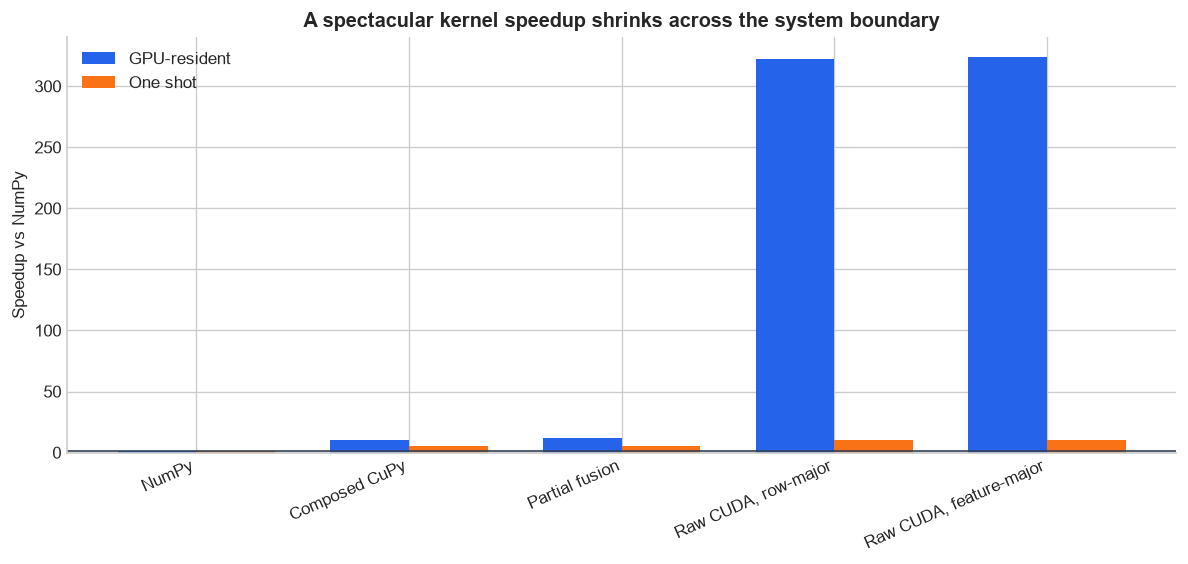

,label,resident_speedup_vs_numpy,one_shot_speedup_vs_numpy,cold_compile_seconds
8,NumPy,1.00,1.00,NaN
6,Composed CuPy,10.03,5.13,NaN
7,Partial fusion,12.15,5.69,0.04
9,"Raw CUDA, row-major",322.58,10.49,0.06
10,"Raw CUDA, feature-major",324.10,10.36,0.06


In [5]:
focus = fusion[(fusion["rows"] == 1_048_576) & (fusion["features"] == 16)].copy()
focus = focus[focus["implementation"].isin(["numpy", "cupy_composed", "cupy_partial_fusion", "raw_aos_b256", "raw_soa_b256"])].copy()
focus["label"] = focus["implementation"].map(LABELS)
order = list(LABELS.values())
focus["label"] = pd.Categorical(focus["label"], order, ordered=True)
focus = focus.sort_values("label")

x = np.arange(len(focus))
width = 0.37
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - width / 2, focus["resident_speedup_vs_numpy"], width, label="GPU-resident", color="#2563eb")
ax.bar(x + width / 2, focus["one_shot_speedup_vs_numpy"], width, label="One shot", color="#f97316")
ax.axhline(1, color="#334155", linewidth=1)
ax.set_xticks(x, focus["label"], rotation=24, ha="right")
ax.set_ylabel("Speedup vs NumPy")
ax.set_title("A spectacular kernel speedup shrinks across the system boundary")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

focus[["label", "resident_speedup_vs_numpy", "one_shot_speedup_vs_numpy", "cold_compile_seconds"]].round(2)

The fully fused raw kernels are roughly **323–324× faster than NumPy when resident**, but about **10.49×** (row-major input) and **10.36×** (feature-major input) in the one-shot path. Ordinary composed CuPy is already useful—**5.13× one shot**—and partial fusion improves that to **5.69×**. A custom kernel must beat a strong framework baseline after the boundaries that the application actually crosses.

## 4. The one-shot crossover arrives before the dramatic speedup

At 16 features, the benchmark sweeps from 1,024 to 16,777,216 rows. This is the practical comparison for a caller starting and ending with NumPy arrays.

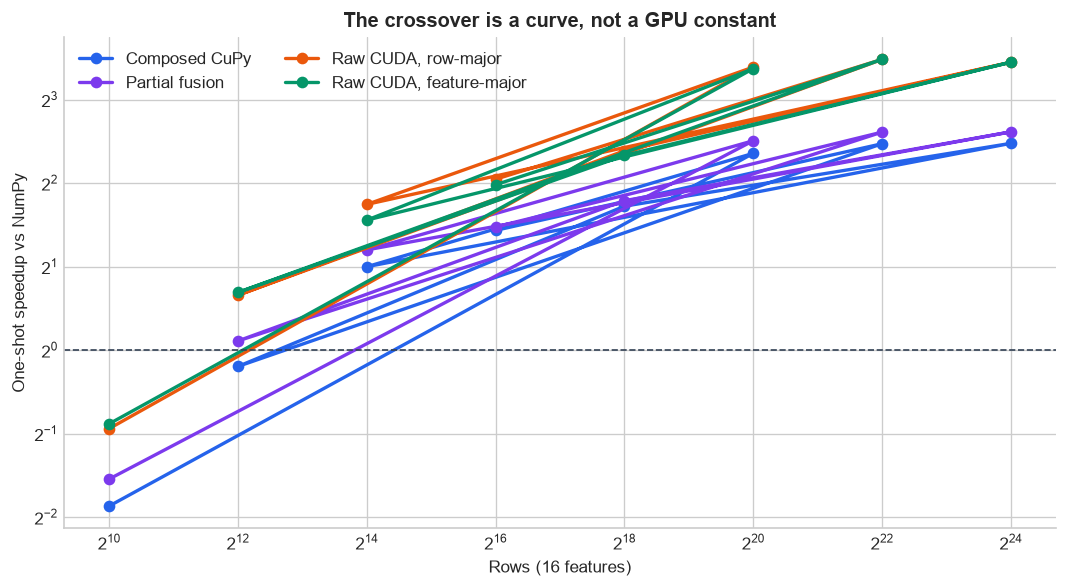

,implementation,first tested win (rows)
1,Partial fusion,4096
2,"Raw CUDA, row-major",4096
3,"Raw CUDA, feature-major",4096
0,Composed CuPy,16384


In [6]:
row_scale = fusion[
    (fusion["features"] == 16)
    & fusion["implementation"].isin(["cupy_composed", "cupy_partial_fusion", "raw_aos_b256", "raw_soa_b256"])
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
for implementation, frame in row_scale.groupby("implementation"):
    label = LABELS[implementation]
    ax.plot(frame["rows"], frame["one_shot_speedup_vs_numpy"], marker="o", linewidth=2, label=label, color=COLORS[label])
ax.axhline(1, color="#334155", linestyle="--", linewidth=1)
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("Rows (16 features)")
ax.set_ylabel("One-shot speedup vs NumPy")
ax.set_title("The crossover is a curve, not a GPU constant")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

crossovers = []
for implementation, frame in row_scale.groupby("implementation"):
    wins = frame[frame["one_shot_speedup_vs_numpy"] > 1].sort_values("rows")
    crossovers.append({"implementation": LABELS[implementation], "first tested win (rows)": int(wins.iloc[0]["rows"])})
pd.DataFrame(crossovers).sort_values("first tested win (rows)")

The raw row-major and feature-major kernels and partial fusion first win at the tested **4,096-row** point. Composed CuPy first wins at **16,384 rows**. Those are bracketed observations, not universal crossover constants: the exact boundary lies between tested sizes and moves with CPU speed, PCIe path, feature width, data type, upstream residency, and downstream reuse.

## 5. A better memory layout is only better if someone pays for it

Feature-major layout lets adjacent threads load adjacent feature values. That becomes valuable on wide rows, but transposing an existing row-major array is not free. The table below compares the steady device-time benefit with the separately measured AoS→SoA conversion cost.

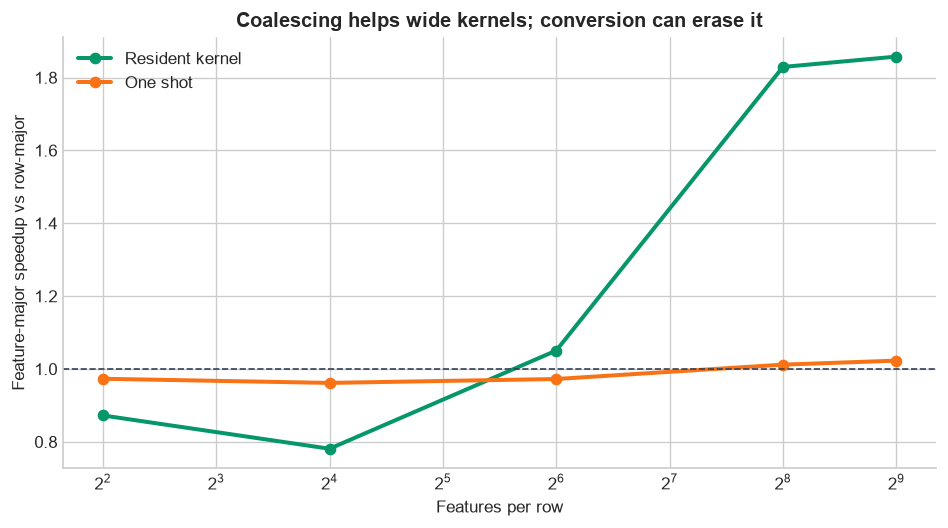

,SOA device speedup vs AOS,SOA one-shot speedup vs AOS,reuses to repay transpose
features,,,
4,0.87,0.97,NaN
16,0.78,0.96,NaN
64,1.05,0.97,65.66
256,1.83,1.01,5.41
512,1.86,1.02,5.41


In [7]:
widths = fusion[(fusion["rows"] == 262_144) & fusion["implementation"].isin(["raw_aos_b256", "raw_soa_b256"])].copy()
pivot = widths.pivot(index="features", columns="implementation", values=["resident_device_seconds", "one_shot_seconds", "aos_to_soa_conversion_seconds"])
layout = pd.DataFrame(index=pivot.index)
layout["SOA device speedup vs AOS"] = pivot["resident_device_seconds"]["raw_aos_b256"] / pivot["resident_device_seconds"]["raw_soa_b256"]
layout["SOA one-shot speedup vs AOS"] = pivot["one_shot_seconds"]["raw_aos_b256"] / pivot["one_shot_seconds"]["raw_soa_b256"]
saved = pivot["resident_device_seconds"]["raw_aos_b256"] - pivot["resident_device_seconds"]["raw_soa_b256"]
layout["reuses to repay transpose"] = np.where(saved > 0, pivot["aos_to_soa_conversion_seconds"]["raw_soa_b256"] / saved, np.inf)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(layout.index, layout["SOA device speedup vs AOS"], marker="o", linewidth=2.4, color="#059669", label="Resident kernel")
ax.plot(layout.index, layout["SOA one-shot speedup vs AOS"], marker="o", linewidth=2.4, color="#f97316", label="One shot")
ax.axhline(1, color="#334155", linestyle="--", linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xlabel("Features per row")
ax.set_ylabel("Feature-major speedup vs row-major")
ax.set_title("Coalescing helps wide kernels; conversion can erase it")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

layout.replace(np.inf, np.nan).round(2)

At 256 features, feature-major layout makes the resident kernel about **1.83× faster**, and the measured transpose repays itself after roughly **5.4 reuses**. At 16 features the two resident kernels are nearly tied; the conversion would need about **1,450 reuses** at 1,048,576 rows and more than **10,000** at 4,194,304 rows. “Use coalesced memory” is sound kernel advice, but “transpose every input” is not sound pipeline advice.

## 6. Occupancy is a diagnostic, not the finish line

The benchmark also sweeps blocks from 32 to 1,024 threads. On this kernel, calculated occupancy changes sharply while normal runtime barely moves.

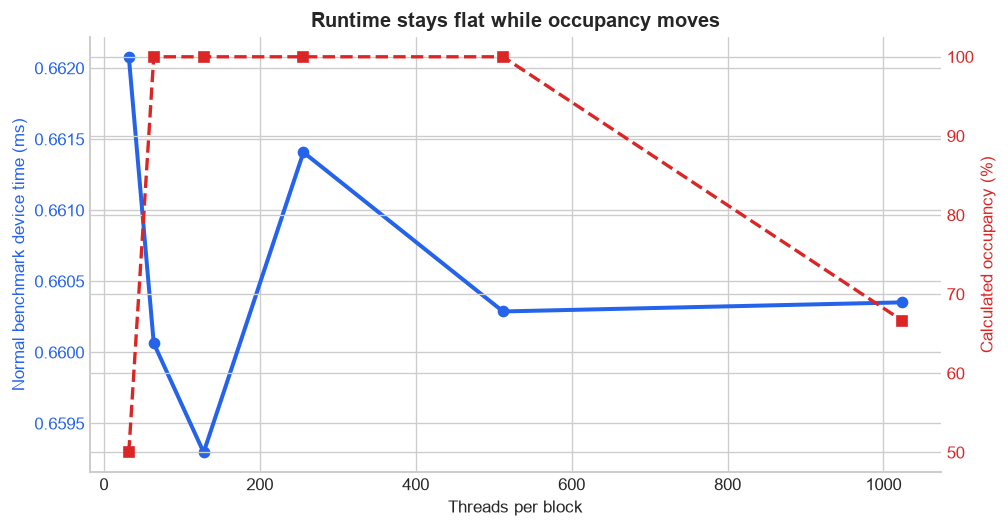

,block_size,registers_per_thread,active_blocks_per_multiprocessor,resident_device_ms,theoretical_occupancy_percent
42,32.0,39.0,24.0,0.662,50.000
44,64.0,39.0,24.0,0.660,100.000
40,128.0,39.0,12.0,0.659,100.000
41,256.0,39.0,6.0,0.661,100.000
43,512.0,39.0,3.0,0.660,100.000
39,1024.0,39.0,1.0,0.660,66.667


In [8]:
blocks = fusion[
    (fusion["rows"] == 262_144)
    & (fusion["features"] == 256)
    & fusion["implementation"].str.startswith("raw_soa_b")
].sort_values("block_size")

fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax1.plot(blocks["block_size"], blocks["resident_device_seconds"] * 1e3, marker="o", linewidth=2.4, color="#2563eb")
ax1.set_xlabel("Threads per block")
ax1.set_ylabel("Normal benchmark device time (ms)", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")
ax2 = ax1.twinx()
ax2.plot(blocks["block_size"], blocks["theoretical_occupancy"] * 100, marker="s", linestyle="--", linewidth=2, color="#dc2626")
ax2.set_ylabel("Calculated occupancy (%)", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")
ax1.set_title("Runtime stays flat while occupancy moves")
fig.tight_layout()
plt.show()

blocks[["block_size", "resident_device_seconds", "registers_per_thread", "active_blocks_per_multiprocessor", "theoretical_occupancy"]].assign(
    resident_device_ms=lambda x: x.pop("resident_device_seconds") * 1e3,
    theoretical_occupancy_percent=lambda x: x.pop("theoretical_occupancy") * 100,
).round(3)

The 32-thread block calculates to **50% occupancy**, 64 through 512 reach **100%**, and 1,024 falls to **66.7%**. Yet device time stays around **0.66 ms**. Choosing 256 is a reasonable default here, not a discovered law. Tune measured workload time and inspect the limiting resource; do not maximize occupancy as an independent objective.

## 7. The profiler explains a mechanism, not the timing table

Nsight Compute replays and instruments kernels, so its durations are intentionally excluded from speed claims. The selected counters below help explain the layout result. `AoS` means row-major and `SoA` means feature-major.

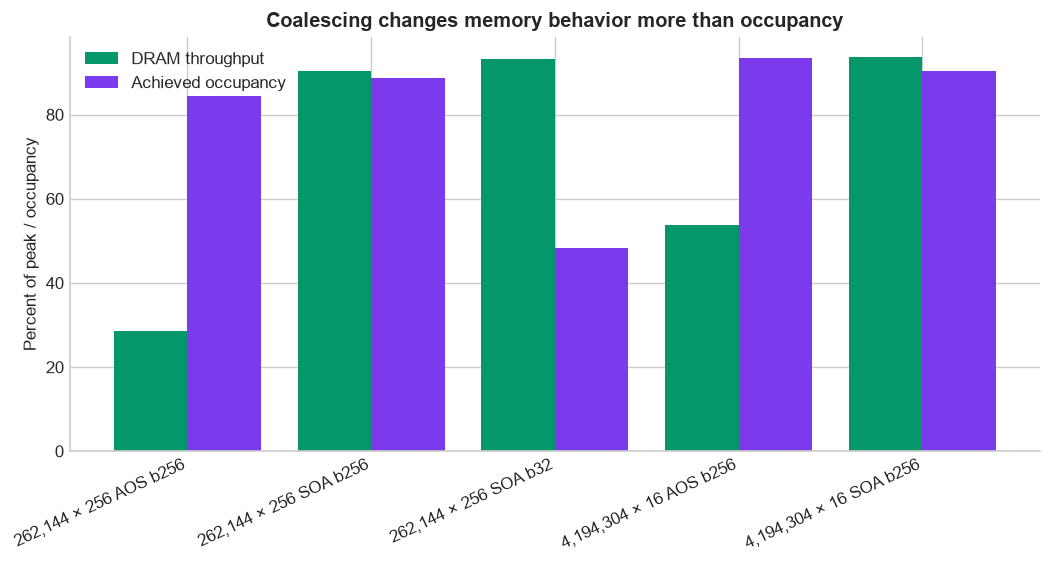

,case,memory_throughput_gbyte_s,dram_throughput_percent,l1_tex_hit_rate_percent,achieved_occupancy_percent
0,"262,144 × 256 AOS b256",97.43,28.67,86.98,84.36
1,"262,144 × 256 SOA b256",306.89,90.32,42.73,88.60
2,"262,144 × 256 SOA b32",316.70,93.19,42.62,48.32
3,"4,194,304 × 16 AOS b256",182.80,53.79,87.92,93.58
4,"4,194,304 × 16 SOA b256",318.67,93.77,41.66,90.41


In [9]:
profile_view = profiles.copy()
profile_view["case"] = profile_view.apply(lambda r: f"{int(r.rows):,} × {int(r.features)} {r.layout.upper()} b{int(r.block_size)}", axis=1)

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(profile_view))
ax.bar(x - 0.2, profile_view["dram_throughput_percent"], 0.4, label="DRAM throughput", color="#059669")
ax.bar(x + 0.2, profile_view["achieved_occupancy_percent"], 0.4, label="Achieved occupancy", color="#7c3aed")
ax.set_xticks(x, profile_view["case"], rotation=25, ha="right")
ax.set_ylabel("Percent of peak / occupancy")
ax.set_title("Coalescing changes memory behavior more than occupancy")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

profile_view[["case", "memory_throughput_gbyte_s", "dram_throughput_percent", "l1_tex_hit_rate_percent", "achieved_occupancy_percent"]].round(2)

For the 256-feature case, feature-major access raises measured memory throughput from **97.43 to 306.89 GB/s** and DRAM throughput from **28.67% to 90.32% of peak** at the same 256-thread block. At 16 features, the row-major kernel's high L1 hit rate helps ordinary runtime remain close even though the profiler reports less DRAM throughput. One counter rarely tells the whole performance story.

## What this experiment supports

1. **Start with NumPy for correctness and with composed CuPy for the first GPU baseline.** High-level code can already win once the batch is large enough.
2. **Fuse a real chain, not a toy operator.** The strongest gain came from eliminating launches, intermediates, and repeated global-memory traffic together.
3. **Keep data resident across stages.** The raw kernel's ~323–324× resident advantage became about 10.4× when the trip across the CPU/GPU boundary was included.
4. **Treat layout as an end-to-end contract.** Feature-major access was valuable for wide rows, but converting narrow row-major inputs could require thousands of reuses to amortize.
5. **Separate cold compilation from steady execution.** This study observed about 44–57 ms for the useful custom kernels and about 102 ms for the tiny launch kernel under isolated empty-cache compilation.
6. **Use occupancy and profiler counters to explain measurements, not replace them.** A 2× occupancy change produced virtually no runtime change in the block sweep.
7. **Publish the slow implementations too.** They show which intuitions survive transfer, layout, and launch costs—and which do not.

These are workstation observations for one dense numeric operation on an RTX PRO 4000 Blackwell SFF. They are mechanisms and decision habits, not universal CUDA constants.

## Reproduce the full GPU study

The `full-benchmark/` directory contains the digest-pinned image, exact Conda package lock, test suite, complete matrix, summarizer, and optional Nsight Compute target. See its README and methodology before running: the full matrix is deliberately much heavier than this analysis notebook.

The notebook itself is safe to rerun on a CPU-only machine:

```bash
python -m venv .venv
source .venv/bin/activate       # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter execute custom_gpu_computing.ipynb --inplace
```